# Perceptron from Scratch: MNIST Study

This notebook reconstructs my 2022 L3 Physics project with tested, deterministic NumPy code. It compares a binary Rosenblatt perceptron with a one-hidden-layer multiclass network.

In [9]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sources.binary import RosenblattPerceptron
from sources.data import filter_binary_digits, load_mnist, normalize_images, resize_images_nearest
from sources.metrics import accuracy, confusion_matrix
from sources.mlp import OneHiddenLayerNetwork
from sources.plotting import plot_confusion, plot_history

## Configuration

Offline mode builds a small digit-like fixture and verifies the full pipeline quickly. Full mode downloads MNIST, caches it under ignored `data/`, resizes images to 14×14 for the multiclass experiment, and takes longer.

In [10]:
RUN_FULL_MNIST = True
SEED = 42
rng = np.random.default_rng(SEED)

if RUN_FULL_MNIST:
    raw_images, labels = load_mnist(Path('..') / 'data')
    images = normalize_images(raw_images)
else:
    # Ten distinct 4×4 prototypes with bounded pixel noise.
    prototypes = np.zeros((10, 16))
    prototypes[np.arange(10), np.arange(10)] = 255
    labels = np.repeat(np.arange(10), 20)
    raw_images = np.clip(prototypes[labels] + rng.normal(0, 12, (len(labels), 16)), 0, 255)
    images = normalize_images(raw_images)

images.shape, labels.shape

((70000, 784), (70000,))

## Binary Rosenblatt perceptron

Digits 0 and 1 are mapped to −1 and +1. A mistaken sample updates weights and bias in the target direction.

Binary accuracy: 99.9%


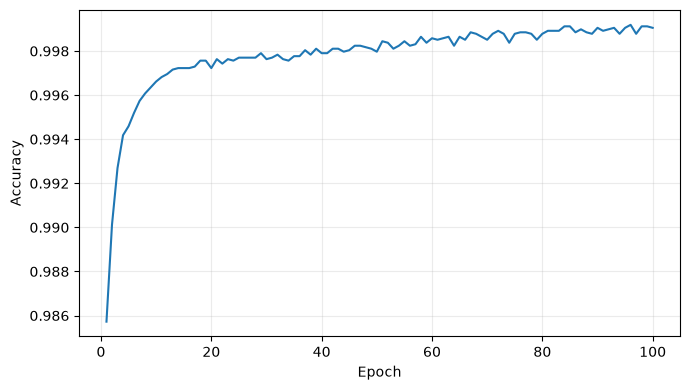

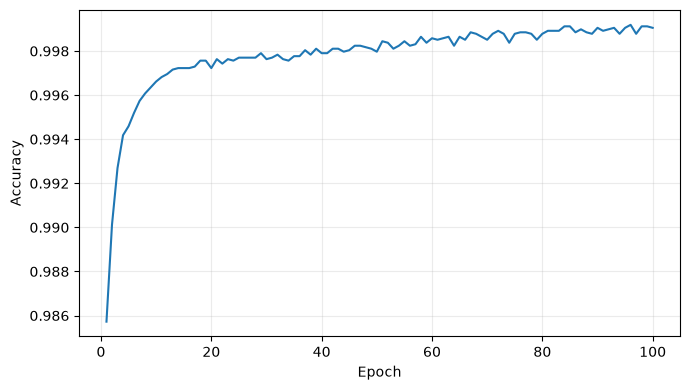

In [11]:
binary_images, binary_labels = filter_binary_digits(images, labels)
binary_model = RosenblattPerceptron(binary_images.shape[1], learning_rate=1e-3, seed=SEED)
binary_history = binary_model.fit(binary_images, binary_labels, epochs=100)
binary_predictions = binary_model.predict(binary_images)
print(f'Binary accuracy: {accuracy(binary_labels, binary_predictions):.1%}')
plot_history(binary_history)

## One-hidden-layer multiclass network

The network uses a ReLU hidden layer, stable softmax probabilities, cross-entropy, and full-batch gradient descent. This stays close to the original educational architecture.

Multiclass accuracy: 80.0%


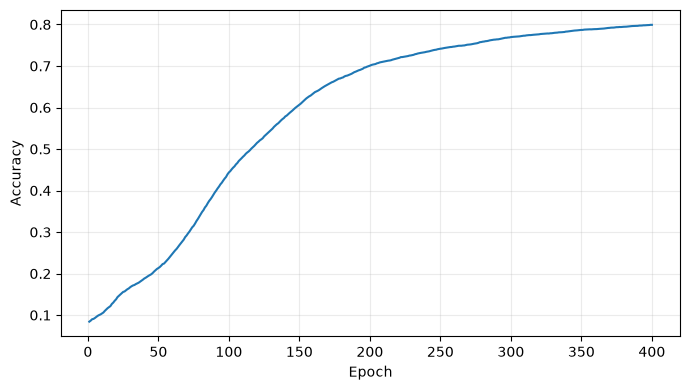

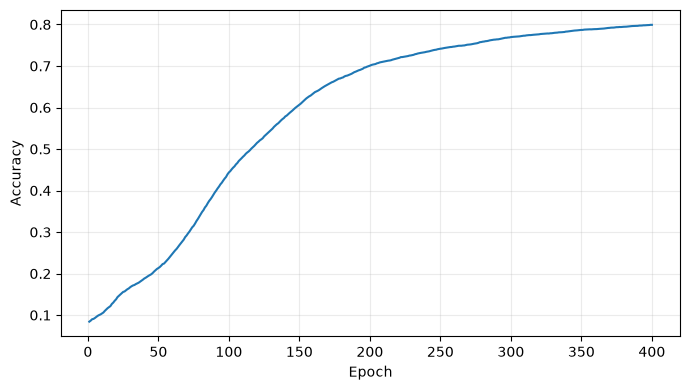

In [12]:
if RUN_FULL_MNIST:
    multiclass_images = resize_images_nearest(images, side=14)[:10_000]
    multiclass_labels = labels[:10_000]
    epochs, learning_rate = 400, 0.04
else:
    multiclass_images, multiclass_labels = images, labels
    epochs, learning_rate = 150, 0.1

network = OneHiddenLayerNetwork(multiclass_images.shape[1], n_hidden=10, n_classes=10, seed=SEED)
multiclass_history = network.fit(multiclass_images, multiclass_labels, epochs=epochs, learning_rate=learning_rate)
multiclass_predictions = network.predict(multiclass_images)
print(f'Multiclass accuracy: {accuracy(multiclass_labels, multiclass_predictions):.1%}')
plot_history(multiclass_history['accuracy'])

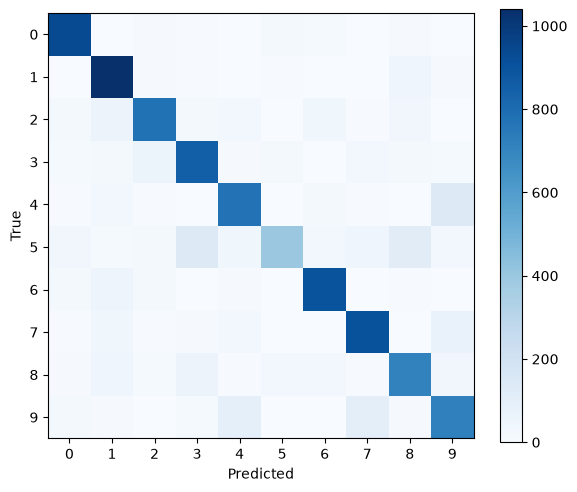

In [13]:
matrix = confusion_matrix(multiclass_labels, multiclass_predictions, n_classes=10)
plot_confusion(matrix, labels=[str(digit) for digit in range(10)]);

## Comparison with the 2022 report

The historical MNIST runs reported fewer than 1% errors for binary 0-vs-1 classification and about 70% accuracy for the small multiclass model. Exact trajectories depend on initialization and training configuration. This reconstruction fixes the random seed, applies softmax per sample, and separates data, model, metric, and plotting concerns while preserving the same model families.